In [1]:
# Cell 1: Import libraries
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from models import (
    train_logistic_regression,
    train_random_forest,
    train_naive_bayes,
    train_lightgbm,
    train_mlp,
    plot_feature_importance
    
)
from utils import (
    plot_confusion_matrix,
    plot_multiple_roc_curves,
    save_metrics_to_json as save_metrics,
)

import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Cell 2: Load preprocessed data
print("Loading preprocessed data...")

X_train = np.load('../data/X_train.npy',allow_pickle=True)
X_test = np.load('../data/X_test.npy',allow_pickle=True)
y_train = np.load('../data/y_train.npy',allow_pickle=True)
y_test = None

# Load feature names
with open('../data/feature_names.txt', 'r') as f:
    feature_names = [line.strip() for line in f.readlines()]

print(f"✓ Data loaded successfully!")
print(f"  Training samples: {X_train.shape[0]:,}")
print(f"  Test samples: {X_test.shape[0]:,}")
print(f"  Features: {X_train.shape[1]}")
print(f"\n  Training class distribution: {np.bincount(y_train)}")
print("Test class distribution: Unavailable (no ground truth for test set)")

Loading preprocessed data...
✓ Data loaded successfully!
  Training samples: 307,511
  Test samples: 48,744
  Features: 256

  Training class distribution: [282686  24825]
Test class distribution: Unavailable (no ground truth for test set)


In [3]:
from sklearn.model_selection import train_test_split

# Split training set into training + validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)



TRAINING LOGISTIC REGRESSION

Training Logistic Regression...
Applying SMOTE to handle class imbalance...
Original class distribution:
0    226148
1     19860
Name: count, dtype: int64
Resampled class distribution:
0    226148
1    226148
Name: count, dtype: int64

Logistic Regression Performance:
  Accuracy:  0.7034
  Precision: 0.1689
  Recall:    0.6822
  F1-Score:  0.2708
  ROC-AUC:   0.7591

✓ Logistic Regression Results:
  Accuracy:  0.7034
  Precision: 0.1689
  Recall:    0.6822
  F1-Score:  0.2708
  ROC-AUC:   0.7591
Confusion matrix saved to ../outputs/lr_confusion_matrix.png


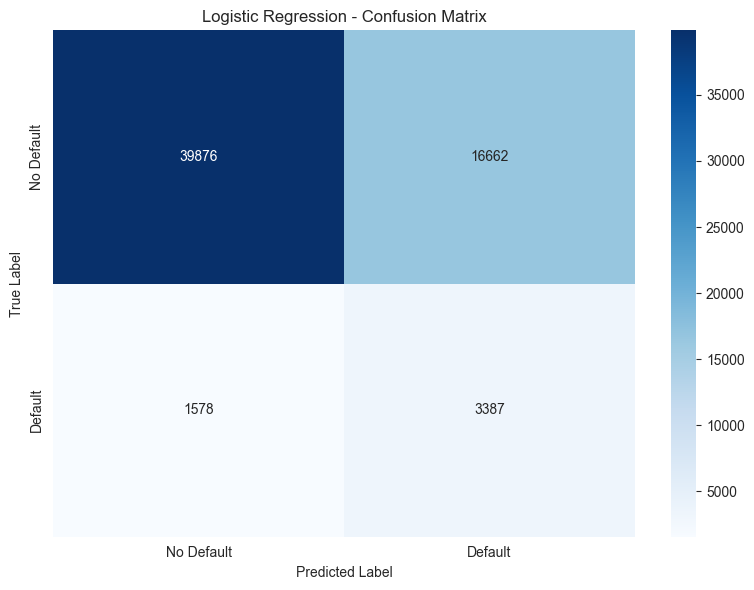

In [4]:
# Cell 3: Train Logistic Regression
print("\n" + "=" * 80)
print("TRAINING LOGISTIC REGRESSION")
print("=" * 80)

lr_model, lr_metrics = train_logistic_regression(X_tr, y_tr, X_val, y_val)

print(f"\n✓ Logistic Regression Results:")
print(f"  Accuracy:  {lr_metrics['accuracy']:.4f}")
print(f"  Precision: {lr_metrics['precision']:.4f}")
print(f"  Recall:    {lr_metrics['recall']:.4f}")
print(f"  F1-Score:  {lr_metrics['f1_score']:.4f}")
print(f"  ROC-AUC:   {lr_metrics['roc_auc']:.4f}")

# Plot confusion matrix using y_val and y_pred
plot_confusion_matrix(
    y_val, 
    lr_metrics['y_pred'],   # <- make sure you return this from `calculate_metrics()`
    title='Logistic Regression - Confusion Matrix',
    save_path='../outputs/lr_confusion_matrix.png'
)


TRAINING RANDOM FOREST

Training Random Forest...
Applying SMOTE to handle class imbalance...
Original class distribution:
0    226148
1     19860
Name: count, dtype: int64
Resampled class distribution:
0    226148
1    226148
Name: count, dtype: int64

Random Forest Performance:
  Accuracy:  0.8872
  Precision: 0.2092
  Recall:    0.1428
  F1-Score:  0.1697
  ROC-AUC:   0.6909

✓ Random Forest Results:
  Accuracy:  0.8872
  Precision: 0.2092
  Recall:    0.1428
  F1-Score:  0.1697
  ROC-AUC:   0.6909
Confusion matrix saved to ../outputs/rf_confusion_matrix.png


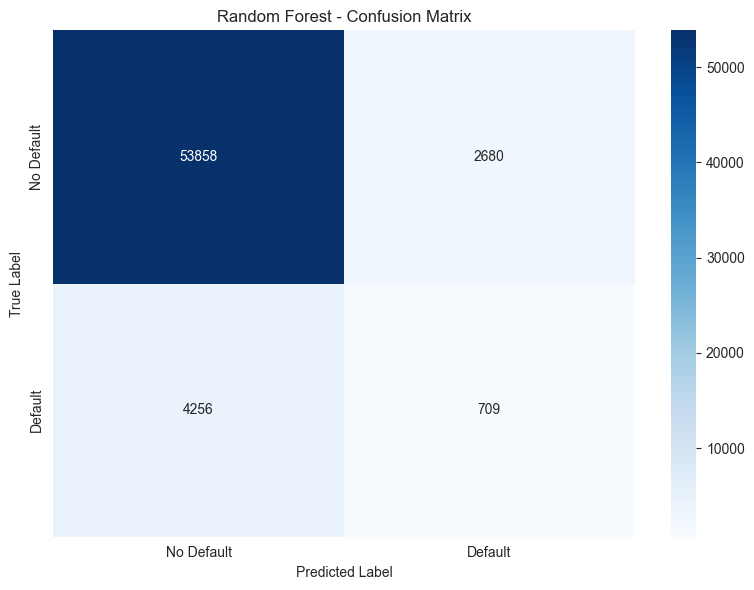

Feature importance plot saved to ../outputs/rf_feature_importance.png


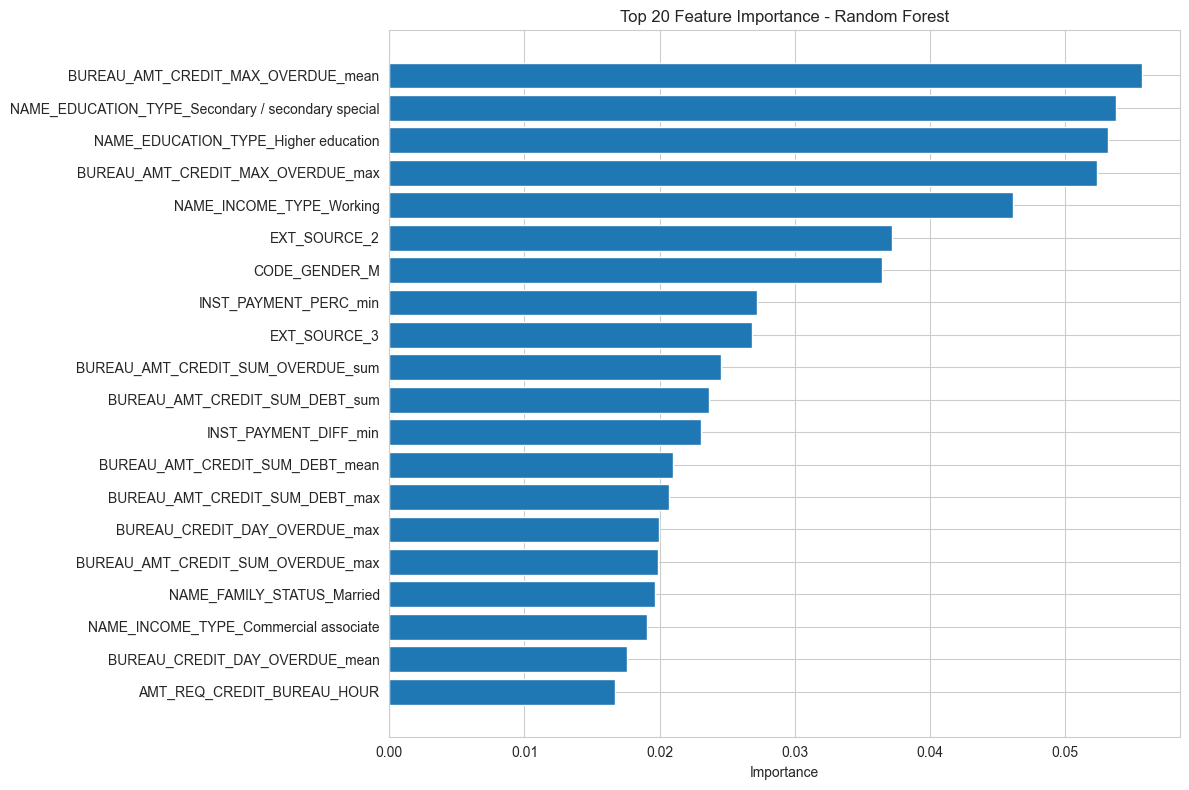

In [7]:
# Cell 4: Train Random Forest

print("\n" + "=" * 80)
print("TRAINING RANDOM FOREST")
print("=" * 80)

rf_model, rf_metrics = train_random_forest(X_tr, y_tr, X_val, y_val)

print(f"\n✓ Random Forest Results:")
print(f"  Accuracy:  {rf_metrics['accuracy']:.4f}")
print(f"  Precision: {rf_metrics['precision']:.4f}")
print(f"  Recall:    {rf_metrics['recall']:.4f}")
print(f"  F1-Score:  {rf_metrics['f1_score']:.4f}")
print(f"  ROC-AUC:   {rf_metrics['roc_auc']:.4f}")

# Plot confusion matrix
plot_confusion_matrix(
    y_val, 
    rf_metrics['y_pred'], 
    title='Random Forest - Confusion Matrix',
    save_path='../outputs/rf_confusion_matrix.png'
)

# Plot feature importance
plot_feature_importance(
    rf_model, 
    feature_names, 
    model_name='Random Forest',
    top_n=20,
    save_path='../outputs/rf_feature_importance.png'
)



TRAINING NAIVE BAYES

Training Naive Bayes...
Applying SMOTE to handle class imbalance...
Original class distribution:
0    226148
1     19860
Name: count, dtype: int64
Resampled class distribution:
0    226148
1    226148
Name: count, dtype: int64

Naive Bayes Performance:
  Accuracy:  0.2112
  Precision: 0.0869
  Recall:    0.9223
  F1-Score:  0.1588
  ROC-AUC:   0.5569

✓ Naive Bayes Results:
  Accuracy:  0.2112
  Precision: 0.0869
  Recall:    0.9223
  F1-Score:  0.1588
  ROC-AUC:   0.5569
Confusion matrix saved to ../outputs/nb_confusion_matrix.png


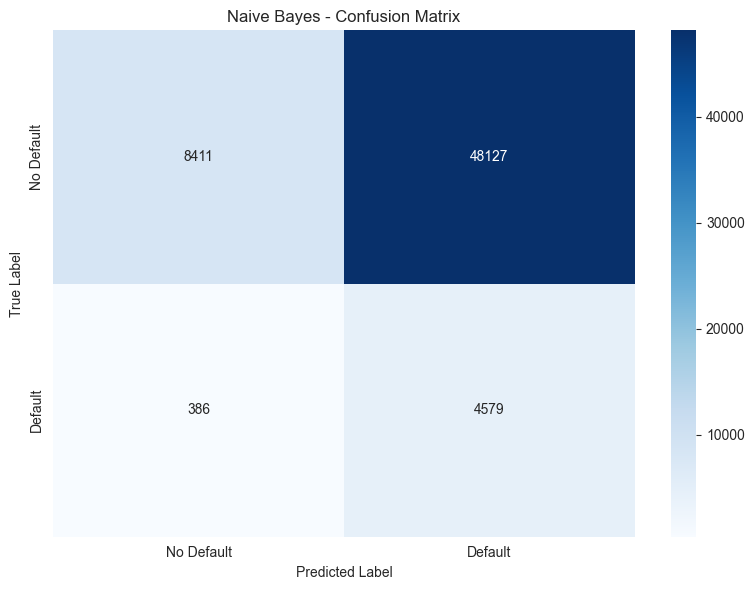

In [8]:
# Cell 5: Train Naive Bayes
print("\n" + "=" * 80)
print("TRAINING NAIVE BAYES")
print("=" * 80)

# Train model and get evaluation metrics
nb_model, nb_metrics = train_naive_bayes(X_tr, y_tr, X_val, y_val)

print(f"\n✓ Naive Bayes Results:")
print(f"  Accuracy:  {nb_metrics['accuracy']:.4f}")
print(f"  Precision: {nb_metrics['precision']:.4f}")
print(f"  Recall:    {nb_metrics['recall']:.4f}")
print(f"  F1-Score:  {nb_metrics['f1_score']:.4f}")
print(f"  ROC-AUC:   {nb_metrics['roc_auc']:.4f}")

# Plot confusion matrix
plot_confusion_matrix(
    y_val, 
    nb_metrics['y_pred'], 
    title='Naive Bayes - Confusion Matrix',
    save_path='../outputs/nb_confusion_matrix.png'
)



TRAINING LIGHTGBM

Training LightGBM...
Applying SMOTE to handle class imbalance...
Original class distribution:
0    226148
1     19860
Name: count, dtype: int64
Resampled class distribution:
0    226148
1    226148
Name: count, dtype: int64
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[475]	valid_0's auc: 0.775451	valid_0's binary_logloss: 0.240693

LightGBM Performance:
  Accuracy:  0.9201
  Precision: 0.5734
  Recall:    0.0409
  F1-Score:  0.0763
  ROC-AUC:   0.7754

✓ LightGBM Results:
  Accuracy:  0.9201
  Precision: 0.5734
  Recall:    0.0409
  F1-Score:  0.0763
  ROC-AUC:   0.7754
Confusion matrix saved to ../outputs/lgbm_confusion_matrix.png


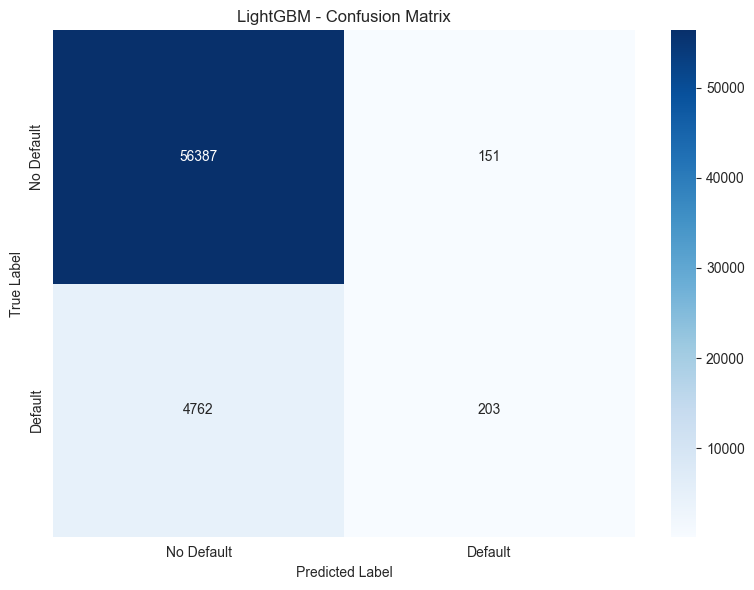

Feature importance plot saved to ../outputs/lgbm_feature_importance.png


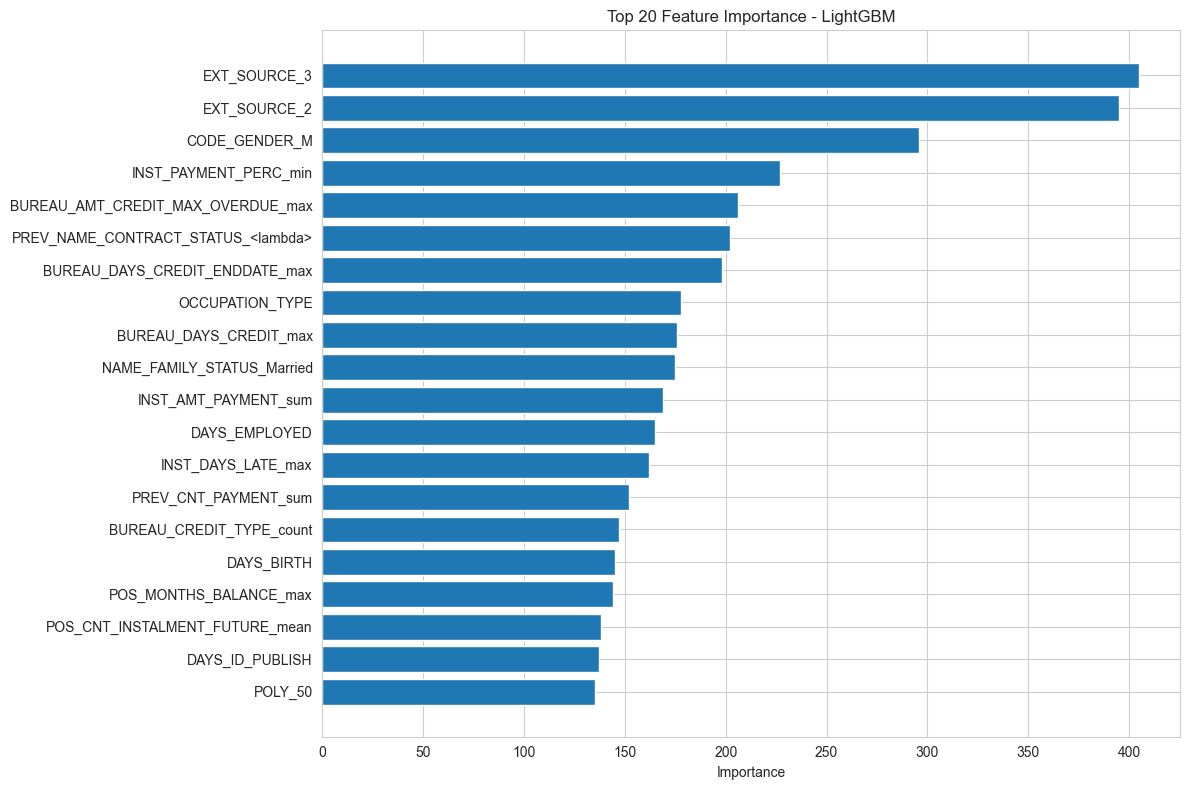

In [9]:
# Cell 6: Train LightGBM
print("\n" + "=" * 80)
print("TRAINING LIGHTGBM")
print("=" * 80)

# Train the LightGBM model
lgbm_model, lgbm_metrics = train_lightgbm(X_tr, y_tr, X_val, y_val)

print(f"\n✓ LightGBM Results:")
print(f"  Accuracy:  {lgbm_metrics['accuracy']:.4f}")
print(f"  Precision: {lgbm_metrics['precision']:.4f}")
print(f"  Recall:    {lgbm_metrics['recall']:.4f}")
print(f"  F1-Score:  {lgbm_metrics['f1_score']:.4f}")
print(f"  ROC-AUC:   {lgbm_metrics['roc_auc']:.4f}")

# Plot confusion matrix
plot_confusion_matrix(
    y_val, 
    lgbm_metrics['y_pred'], 
    title='LightGBM - Confusion Matrix',
    save_path='../outputs/lgbm_confusion_matrix.png'
)

# Plot feature importance
plot_feature_importance(
    lgbm_model, 
    feature_names, 
    'LightGBM',
    top_n=20,
    save_path='../outputs/lgbm_feature_importance.png'
)



TRAINING MLP NEURAL NETWORK

Training Multi-Layer Perceptron...
Applying SMOTE to handle class imbalance...
Original class distribution:
0    226148
1     19860
Name: count, dtype: int64
Resampled class distribution:
0    226148
1    226148
Name: count, dtype: int64

MLP Neural Network Performance:
  Accuracy:  0.8629
  Precision: 0.1818
  Recall:    0.1996
  F1-Score:  0.1903
  ROC-AUC:   0.6715

✓ MLP Neural Network Results:
  Accuracy:  0.8629
  Precision: 0.1818
  Recall:    0.1996
  F1-Score:  0.1903
  ROC-AUC:   0.6715
Confusion matrix saved to ../outputs/mlp_confusion_matrix.png


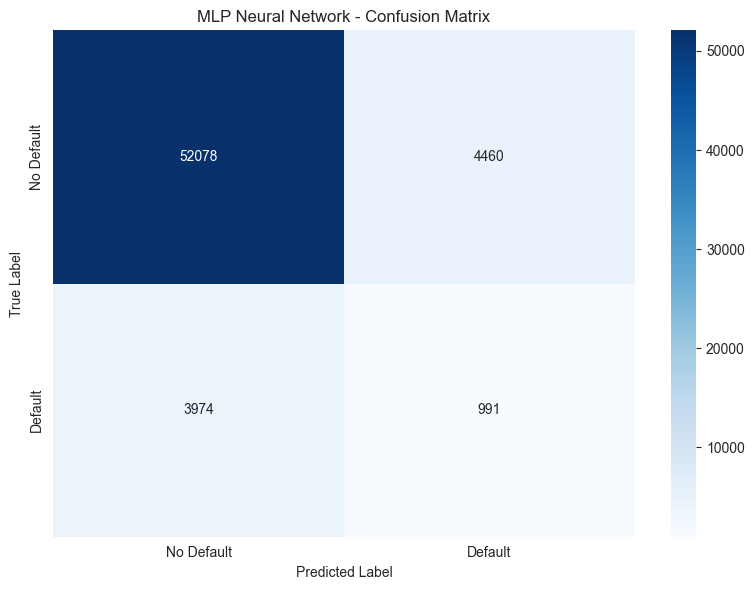

In [8]:
# Cell 7: Train MLP (Neural Network)


print("\n" + "=" * 80)
print("TRAINING MLP NEURAL NETWORK")
print("=" * 80)

mlp_model, mlp_metrics = train_mlp(X_tr, y_tr, X_val, y_val)

print(f"\n✓ MLP Neural Network Results:")
print(f"  Accuracy:  {mlp_metrics['accuracy']:.4f}")
print(f"  Precision: {mlp_metrics['precision']:.4f}")
print(f"  Recall:    {mlp_metrics['recall']:.4f}")
print(f"  F1-Score:  {mlp_metrics['f1_score']:.4f}")
print(f"  ROC-AUC:   {mlp_metrics['roc_auc']:.4f}")

# Plot confusion matrix
plot_confusion_matrix(
    y_val, 
    mlp_metrics['y_pred'], 
    title='MLP Neural Network - Confusion Matrix',
    save_path='../outputs/mlp_confusion_matrix.png'
)

In [10]:
# Cell 8: Compare all models
print("\n" + "=" * 80)
print("MODEL COMPARISON")
print("=" * 80)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Naive Bayes', 'LightGBM'],
    'Accuracy': [lr_metrics['accuracy'], rf_metrics['accuracy'], nb_metrics['accuracy'], 
                 lgbm_metrics['accuracy']],
    'Precision': [lr_metrics['precision'], rf_metrics['precision'], nb_metrics['precision'],
                  lgbm_metrics['precision']],
    'Recall': [lr_metrics['recall'], rf_metrics['recall'], nb_metrics['recall'],
               lgbm_metrics['recall']],
    'F1-Score': [lr_metrics['f1_score'], rf_metrics['f1_score'], nb_metrics['f1_score'],
                 lgbm_metrics['f1_score']],
    'ROC-AUC': [lr_metrics['roc_auc'], rf_metrics['roc_auc'], nb_metrics['roc_auc'],
                lgbm_metrics['roc_auc']]
})

print("\nPerformance Metrics Comparison:")
print(comparison_df.to_string(index=False))

# Save comparison
comparison_df.to_csv('../outputs/model_comparison.csv', index=False)
print("\n✓ Comparison saved to outputs/model_comparison.csv")


MODEL COMPARISON

Performance Metrics Comparison:
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.703429   0.168936 0.682175  0.270808 0.759117
      Random Forest  0.887225   0.209206 0.142800  0.169739 0.690943
        Naive Bayes  0.211209   0.086878 0.922256  0.158797 0.556902
           LightGBM  0.920118   0.573446 0.040886  0.076330 0.775447

✓ Comparison saved to outputs/model_comparison.csv


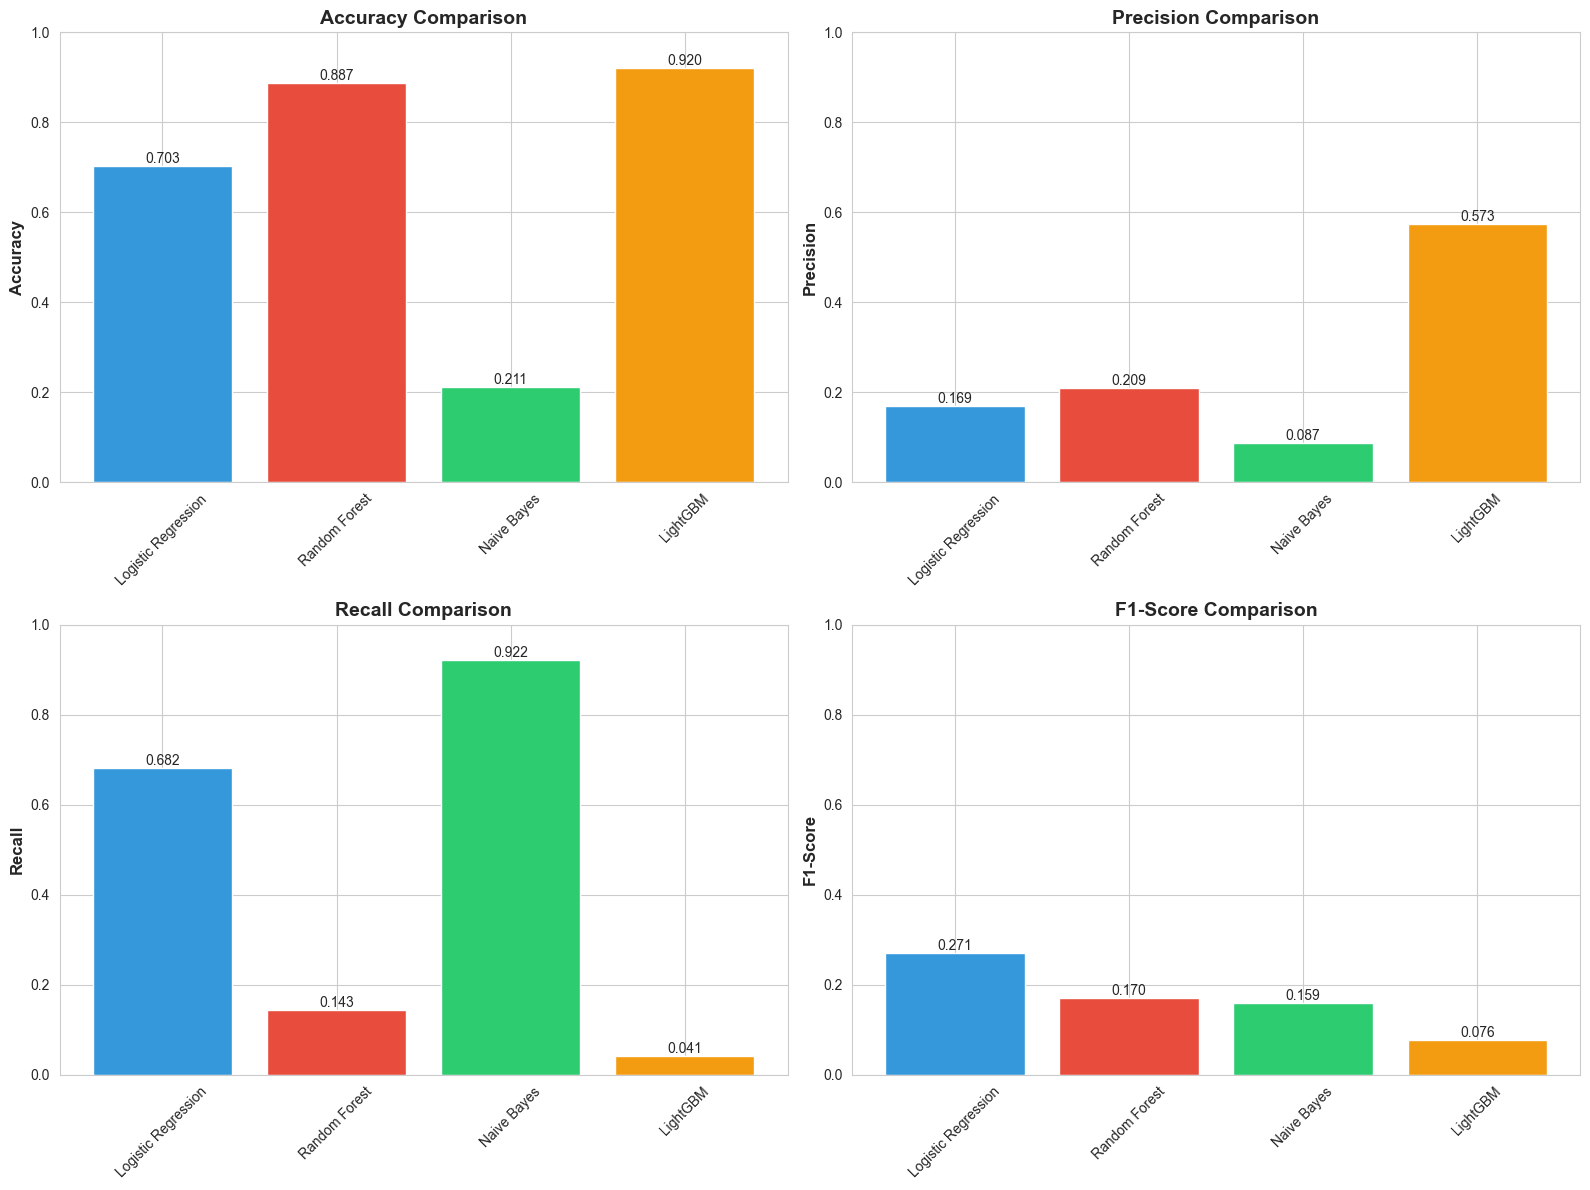

In [11]:
# Cell 9: Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    bars = ax.bar(comparison_df['Model'], comparison_df[metric], color=colors)
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


ROC CURVES COMPARISON
ROC curves saved to ../outputs/roc_curves_comparison.png


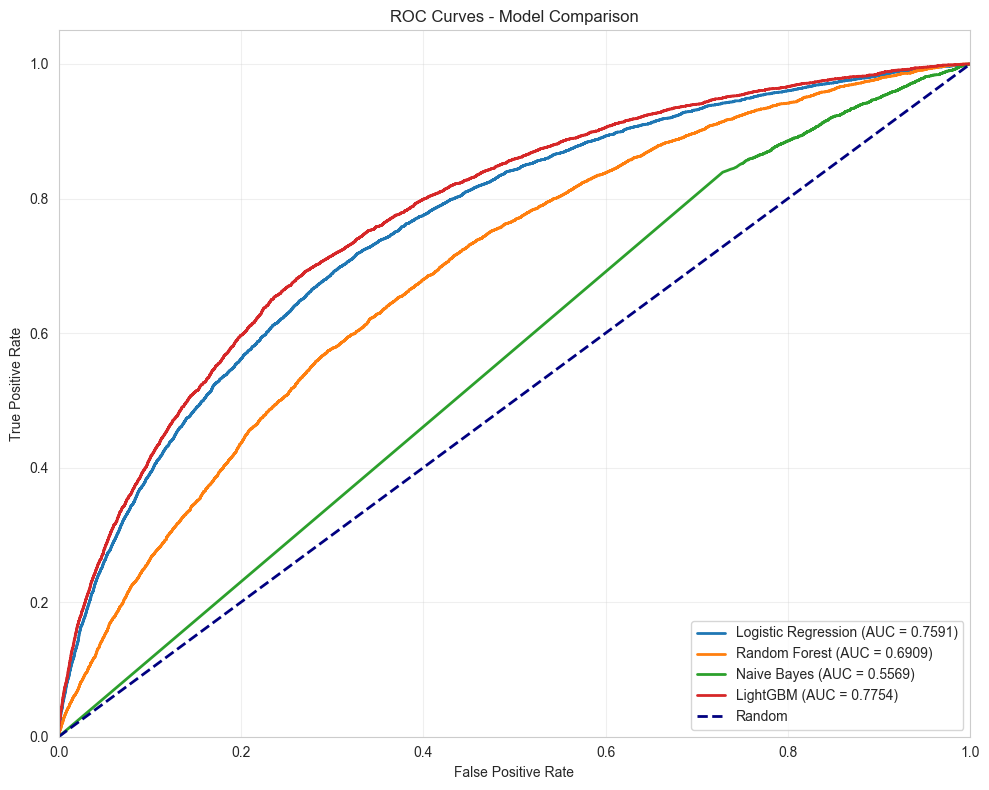

In [12]:
# Cell 10: ROC Curves Comparison
print("\n" + "=" * 80)
print("ROC CURVES COMPARISON")
print("=" * 80)

models_dict = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'Naive Bayes': nb_model,
    'LightGBM': lgbm_model
}

plot_multiple_roc_curves(models_dict, X_val, y_val, save_path='../outputs/roc_curves_comparison.png')


In [13]:
# Cell 11: Best model identification
print("\n" + "=" * 80)
print("BEST MODEL IDENTIFICATION")
print("=" * 80)

best_f1_idx = comparison_df['F1-Score'].idxmax()
best_roc_idx = comparison_df['ROC-AUC'].idxmax()
best_recall_idx = comparison_df['Recall'].idxmax()

print(f"\n🏆 Best Model by F1-Score: {comparison_df.loc[best_f1_idx, 'Model']}")
print(f"   F1-Score: {comparison_df.loc[best_f1_idx, 'F1-Score']:.4f}")

print(f"\n🏆 Best Model by ROC-AUC: {comparison_df.loc[best_roc_idx, 'Model']}")
print(f"   ROC-AUC: {comparison_df.loc[best_roc_idx, 'ROC-AUC']:.4f}")

print(f"\n🏆 Best Model by Recall: {comparison_df.loc[best_recall_idx, 'Model']}")
print(f"   Recall: {comparison_df.loc[best_recall_idx, 'Recall']:.4f}")


BEST MODEL IDENTIFICATION

🏆 Best Model by F1-Score: Logistic Regression
   F1-Score: 0.2708

🏆 Best Model by ROC-AUC: LightGBM
   ROC-AUC: 0.7754

🏆 Best Model by Recall: Naive Bayes
   Recall: 0.9223


In [14]:
# Cell 12: Detailed analysis of best model
best_model_name = comparison_df.loc[best_f1_idx, 'Model']
print(f"\n" + "=" * 80)
print(f"DETAILED ANALYSIS: {best_model_name.upper()}")
print("=" * 80)

if best_model_name == 'Logistic Regression':
    best_metrics = lr_metrics
elif best_model_name == 'Random Forest':
    best_metrics = rf_metrics
elif best_model_name == 'Naive Bayes':
    best_metrics = nb_metrics
else:
    best_metrics = lgbm_metrics

# 🧠 Use sklearn directly to print the classification report
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_val, best_metrics['y_pred'], digits=4))



DETAILED ANALYSIS: LOGISTIC REGRESSION

Classification Report:
              precision    recall  f1-score   support

           0     0.9619    0.7053    0.8139     56538
           1     0.1689    0.6822    0.2708      4965

    accuracy                         0.7034     61503
   macro avg     0.5654    0.6937    0.5423     61503
weighted avg     0.8979    0.7034    0.7700     61503



In [19]:
from utils import save_metrics_to_json  # or save_metrics_json if renamed
from models import save_metrics         # this is your CSV writer

import os

print("\n" + "=" * 80)
print("SAVING METRICS")
print("=" * 80)

# Make sure the directory exists
os.makedirs('../outputs/metrics/', exist_ok=True)

# Save each model’s metrics
save_metrics(pd.DataFrame([lr_metrics]), '../outputs/metrics/lr_metrics.csv')
save_metrics(pd.DataFrame([rf_metrics]), '../outputs/metrics/rf_metrics.csv')
save_metrics(pd.DataFrame([nb_metrics]), '../outputs/metrics/nb_metrics.csv')
save_metrics(pd.DataFrame([lgbm_metrics]), '../outputs/metrics/lgbm_metrics.csv')



SAVING METRICS

Metrics saved to ../outputs/metrics/lr_metrics.csv

Metrics saved to ../outputs/metrics/rf_metrics.csv

Metrics saved to ../outputs/metrics/nb_metrics.csv

Metrics saved to ../outputs/metrics/lgbm_metrics.csv


In [20]:
# Cell 14: Model insights
print("\n" + "=" * 80)
print("KEY INSIGHTS")
print("=" * 80)

avg_accuracy = comparison_df['Accuracy'].mean()
avg_f1 = comparison_df['F1-Score'].mean()
avg_roc_auc = comparison_df['ROC-AUC'].mean()

print(f"""
Performance Summary:
--------------------
• Average Accuracy across models: {avg_accuracy:.4f}
• Average F1-Score across models: {avg_f1:.4f}
• Average ROC-AUC across models: {avg_roc_auc:.4f}

• Best performing model (F1): {comparison_df.loc[best_f1_idx, 'Model']} ({comparison_df.loc[best_f1_idx, 'F1-Score']:.4f})
• Model with highest recall: {comparison_df.loc[best_recall_idx, 'Model']} ({comparison_df.loc[best_recall_idx, 'Recall']:.4f})

Observations:
-------------
1. Tree-based models (RF, LightGBM) typically perform well on structured data
2. High recall is crucial for credit default prediction (minimize false negatives)
3. Class imbalance was handled using SMOTE and class weights
4. Feature engineering and preprocessing significantly impact performance
""")


KEY INSIGHTS

Performance Summary:
--------------------
• Average Accuracy across models: 0.6805
• Average F1-Score across models: 0.1689
• Average ROC-AUC across models: 0.6956

• Best performing model (F1): Logistic Regression (0.2708)
• Model with highest recall: Naive Bayes (0.9223)

Observations:
-------------
1. Tree-based models (RF, LightGBM) typically perform well on structured data
2. High recall is crucial for credit default prediction (minimize false negatives)
3. Class imbalance was handled using SMOTE and class weights
4. Feature engineering and preprocessing significantly impact performance



In [22]:
# Cell 15: Summary and next steps
print("\n" + "=" * 80)
print("MODEL TRAINING COMPLETE")
print("=" * 80)
print(f"""
Summary:
--------
✓ Trained 4 different ML models
✓ Generated confusion matrices for all models
✓ Created feature importance plots for tree-based models
✓ Compared model performance across metrics
✓ Saved all metrics and visualizations

Generated Outputs:
------------------
• Model comparison charts
• ROC curves comparison
• Confusion matrices (5 models)
• Feature importance plots (RF, LightGBM)
• Metrics CSV files

Next Steps:
-----------
→ Run 03_Clustering_Analysis.ipynb for cluster-based modeling
→ Perform hyperparameter tuning on best model
→ Consider ensemble methods for improved performance
""")


MODEL TRAINING COMPLETE

Summary:
--------
✓ Trained 4 different ML models
✓ Generated confusion matrices for all models
✓ Created feature importance plots for tree-based models
✓ Compared model performance across metrics
✓ Saved all metrics and visualizations

Generated Outputs:
------------------
• Model comparison charts
• ROC curves comparison
• Confusion matrices (5 models)
• Feature importance plots (RF, LightGBM)
• Metrics CSV files

Next Steps:
-----------
→ Run 03_Clustering_Analysis.ipynb for cluster-based modeling
→ Perform hyperparameter tuning on best model
→ Consider ensemble methods for improved performance

